In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
training_data_parquest = pd.read_parquet("../data/processed/training_data.parquet")

In [4]:
# print the column names:
print("Columns in the training dataset:")
print(training_data_parquest.columns.tolist())

Columns in the training dataset:
['LapTimeSec', 'Compound', 'TrackName', 'Driver', 'Team', 'TireAge', 'TireAgeSq', 'RaceLapNumber', 'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'GapToCarAhead', 'DRS_Available', 'CircuitLength', 'NumberOfCorners', 'RaceID', 'LapNumber', 'PitLossSec', 'TotalRaceLaps']


/var/folders/63/__1p4tt55zq_byscd0qttqcc0000gn/T/ipykernel_13650/2914691638.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  races["year"] = races.apply(lambda x: int(x.split("_")[0]))


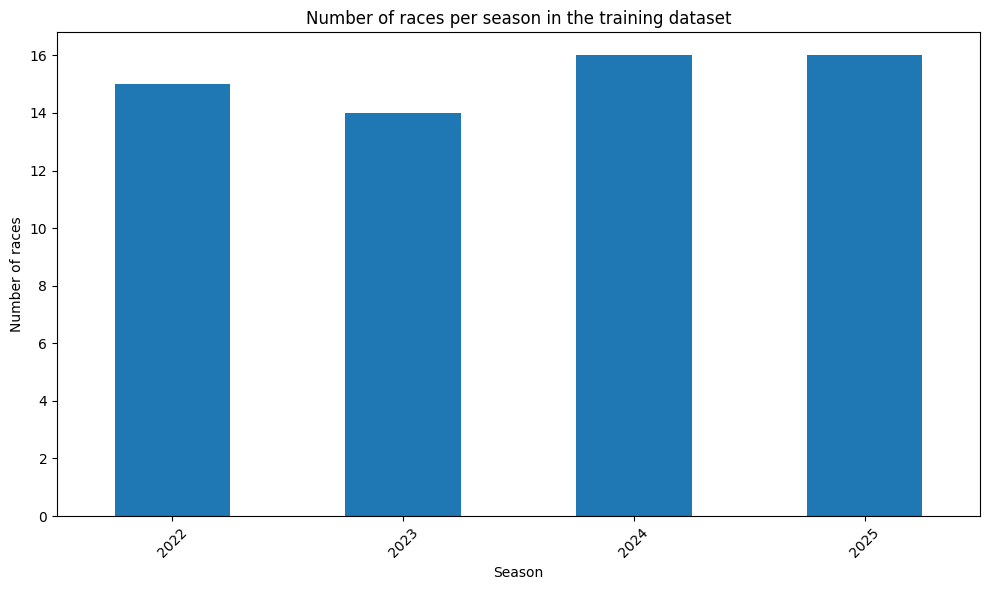

In [19]:
# visualise number of races per season
races= training_data_parquest["RaceID"]
# split into categories via the race id- since it includes the season
races["year"] = races.apply(lambda x: int(x.split("_")[0]))
training_data_parquest["year"] = (
training_data_parquest["RaceID"]
.str.split("_").str[0]
.astype(int)
)
race_counts = (
training_data_parquest[["RaceID", "year"]]
.drop_duplicates()
.groupby("year")
.size()
)
race_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Number of races per season in the training dataset")
plt.xlabel("Season")
plt.ylabel("Number of races")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# print the races ids from each year
for year in sorted(training_data_parquest["year"].unique()):
    races_in_year = training_data_parquest[training_data_parquest["year"] == year]["RaceID"].unique()
    print(f"Races in {year}: {',\n '.join(races_in_year)}")

Races in 2022: 2022_Bahrain Grand Prix,
 2022_Saudi Arabian Grand Prix,
 2022_Australian Grand Prix,
 2022_Miami Grand Prix,
 2022_Spanish Grand Prix,
 2022_Azerbaijan Grand Prix,
 2022_Canadian Grand Prix,
 2022_British Grand Prix,
 2022_French Grand Prix,
 2022_Belgian Grand Prix,
 2022_Dutch Grand Prix,
 2022_Italian Grand Prix,
 2022_United States Grand Prix,
 2022_Mexico City Grand Prix,
 2022_Abu Dhabi Grand Prix
Races in 2023: 2023_Bahrain Grand Prix,
 2023_Saudi Arabian Grand Prix,
 2023_Australian Grand Prix,
 2023_Miami Grand Prix,
 2023_Spanish Grand Prix,
 2023_Canadian Grand Prix,
 2023_British Grand Prix,
 2023_Hungarian Grand Prix,
 2023_Italian Grand Prix,
 2023_Singapore Grand Prix,
 2023_Japanese Grand Prix,
 2023_Mexico City Grand Prix,
 2023_Las Vegas Grand Prix,
 2023_Abu Dhabi Grand Prix
Races in 2024: 2024_Bahrain Grand Prix,
 2024_Saudi Arabian Grand Prix,
 2024_Australian Grand Prix,
 2024_Japanese Grand Prix,
 2024_Emilia Romagna Grand Prix,
 2024_Monaco Grand